In [6]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict


In [13]:
# define state
class BMIState(TypedDict):
    weight_kg: float  # in kg
    height_m: float  # in meters
    bmi: float  # calculated BMI 
    type: str  # BMI category (e.g., Underweight, Normal weight, Overweight, Obesity)

In [14]:
def calculate_bmi(state: BMIState) -> BMIState:
    
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    
    state['bmi'] = round(bmi, 2)
    
    return state

In [15]:
def identify_type(state : BMIState) -> BMIState:
    
    bmi = state['bmi']
    if bmi < 18.5:
        state['type'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['type'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['type'] = 'Overweight'
    else:
        state['type'] = 'Obesity'
        
    return state

In [16]:
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("identify_type", identify_type)

# add  edges to graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "identify_type")
graph.add_edge("identify_type", END)

#compile graph
workflow = graph.compile()

In [17]:
#execute graph
initial_state = {'weight_kg':82,"height_m":1.778}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 82, 'height_m': 1.778, 'bmi': 25.94, 'type': 'Overweight'}


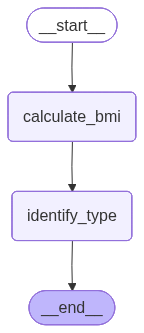

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())